In [1]:
# ============================================================
# CELL 1 - IMPORT LIBRARIES
# ============================================================

import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, datasets

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

TensorFlow Version: 2.21.0
NumPy Version: 2.5.2
Pandas Version: 3.0.3


In [2]:
# ============================================================
# CELL 2 - CHECK GPU
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [3]:
# ============================================================
# CELL 3 - SET RANDOM SEEDS
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [4]:
# ============================================================
# CELL 4 - CREATE RESULTS FOLDER
# ============================================================

RESULTS_DIR = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results folder:", RESULTS_DIR)

Results folder: results


In [5]:
# ============================================================
# CELL 5 - DOWNLOAD CIFAR-100 DATASET TO SELECTED FOLDER
# ============================================================

import os
import urllib.request
import tarfile

# Selected dataset folder
DATASET_DIR = r"C:\Users\adity\OneDrive\Desktop\Assignment 5\CIFAR-100"

# Create folder
os.makedirs(DATASET_DIR, exist_ok=True)

# CIFAR-100 dataset URL
url = "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"

# File paths
tar_path = os.path.join(DATASET_DIR, "cifar-100-python.tar.gz")

print("Dataset folder:")
print(DATASET_DIR)

# Download dataset
if not os.path.exists(tar_path):
    print("\nDownloading CIFAR-100...")
    urllib.request.urlretrieve(url, tar_path)
    print("Download completed!")
else:
    print("\nDataset archive already exists.")

# Extract dataset
extract_folder = os.path.join(DATASET_DIR, "cifar-100-python")

if not os.path.exists(extract_folder):
    print("\nExtracting dataset...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(DATASET_DIR)
    print("Extraction completed!")
else:
    print("\nDataset is already extracted.")

print("\nFiles:")
print(os.listdir(DATASET_DIR))

Dataset folder:
C:\Users\adity\OneDrive\Desktop\Assignment 5\CIFAR-100

Download completed!

Extracting dataset...


C:\Users\adity\AppData\Local\Temp\ipykernel_10016\1515105833.py:38: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATASET_DIR)


Extraction completed!

Files:
['cifar-100-python', 'cifar-100-python.tar.gz']


In [6]:
# ============================================================
# CELL 6 - LOAD CIFAR-100 FROM LOCAL FOLDER
# ============================================================

import pickle
import numpy as np

DATASET_DIR = r"C:\Users\adity\OneDrive\Desktop\Assignment 5\CIFAR-100\cifar-100-python"

def load_cifar_file(file_path):
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="bytes")
    
    images = data[b"data"]
    labels = data[b"fine_labels"]
    
    # Convert from (N, 3072) to (N, 32, 32, 3)
    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)
    
    return images, np.array(labels)

# Load training data
train_images, train_labels = load_cifar_file(
    os.path.join(DATASET_DIR, "train")
)

# Load testing data
test_images, test_labels = load_cifar_file(
    os.path.join(DATASET_DIR, "test")
)

# Reshape labels
train_labels = train_labels.reshape(-1, 1)
test_labels = test_labels.reshape(-1, 1)

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)

print("Testing images:", test_images.shape)
print("Testing labels:", test_labels.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [7]:
# ============================================================
# CELL 7 - NORMALIZE DATA
# ============================================================

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


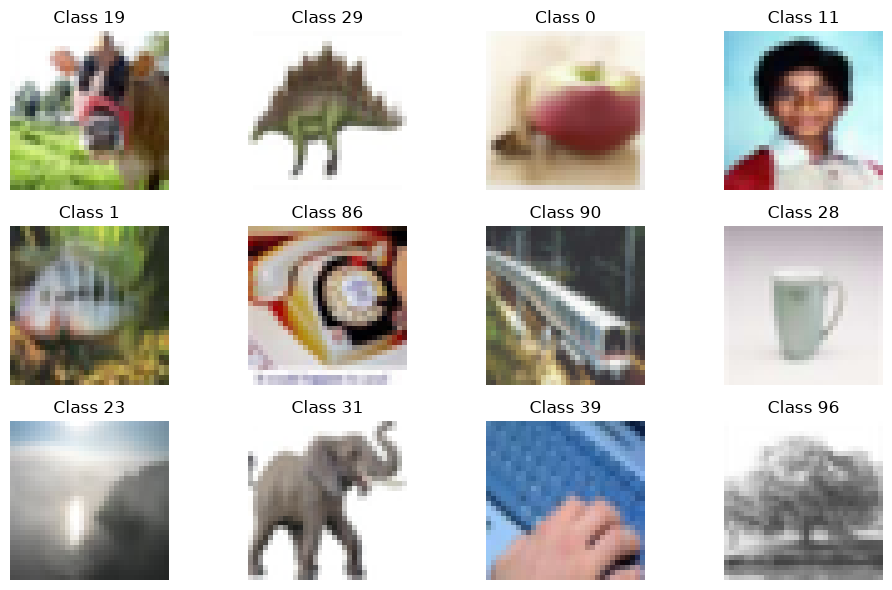

In [8]:
# ============================================================
# CELL 8 - DISPLAY SAMPLE CIFAR-100 IMAGES
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(train_images[i])
    plt.axis("off")
    plt.title(f"Class {train_labels[i]}")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# CELL 9 - CREATE TRAINING AND VALIDATION DATA
# ============================================================

validation_size = 5000

x_val = train_images[-validation_size:]
y_val = train_labels[-validation_size:]

x_train = train_images[:-validation_size]
y_train = train_labels[:-validation_size]

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Test data:", test_images.shape)

Training data: (45000, 32, 32, 3)
Validation data: (5000, 32, 32, 3)
Test data: (10000, 32, 32, 3)


In [10]:
# ============================================================
# CELL 10 - DEFINE CNN MODEL
# ============================================================

def create_model():
    
    model = models.Sequential([
        
        layers.Input(shape=(32, 32, 3)),
        
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        
        layers.Flatten(),
        
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        
        layers.Dense(100, activation="softmax")
    ])
    
    return model

In [11]:
# ============================================================
# CELL 11 - DISPLAY MODEL SUMMARY
# ============================================================

model = create_model()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,216,356 (8.45 MB)

 Trainable params: 2,216,356 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ============================================================
# CELL 12 - DEFINE OPTIMIZERS
# ============================================================

def get_optimizer(name):
    
    if name == "SGD":
        return optimizers.SGD(learning_rate=0.01)
    
    elif name == "Adam":
        return optimizers.Adam(learning_rate=0.001)
    
    elif name == "Adagrad":
        return optimizers.Adagrad(learning_rate=0.01)
    
    elif name == "RMSprop":
        return optimizers.RMSprop(learning_rate=0.001)
    
    elif name == "Nadam":
        return optimizers.Nadam(learning_rate=0.001)
    
    else:
        raise ValueError("Unknown optimizer")

In [13]:
# ============================================================
# CELL 13 - OPTIMIZER LIST
# ============================================================

optimizer_names = [
    "SGD",
    "Adam",
    "Adagrad",
    "RMSprop",
    "Nadam"
]

print("Optimizers to compare:")

for optimizer in optimizer_names:
    print("-", optimizer)

Optimizers to compare:
- SGD
- Adam
- Adagrad
- RMSprop
- Nadam


In [14]:
# ============================================================
# CELL 14 - TRAINING CONFIGURATION
# ============================================================

EPOCHS = 10
BATCH_SIZE = 128

print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Epochs: 10
Batch size: 128


In [15]:
# ============================================================
# CELL 15 - TRAIN USING ALL OPTIMIZERS
# ============================================================

histories = {}
results = []

for optimizer_name in optimizer_names:
    
    print("\n" + "=" * 60)
    print("Training with:", optimizer_name)
    print("=" * 60)
    
    # Create a fresh model
    model = create_model()
    
    # Create optimizer
    optimizer = get_optimizer(optimizer_name)
    
    # Compile model
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    # Start timer
    start_time = time.time()
    
    # Train
    history = model.fit(
        x_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_val, y_val),
        verbose=1
    )
    
    # End timer
    end_time = time.time()
    
    training_time = end_time - start_time
    
    # Save history
    histories[optimizer_name] = history.history
    
    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(
        test_images,
        test_labels,
        verbose=0
    )
    
    # Get best validation accuracy
    best_val_accuracy = max(history.history["val_accuracy"])
    
    # Get final training accuracy
    final_train_accuracy = history.history["accuracy"][-1]
    
    # Get final validation accuracy
    final_val_accuracy = history.history["val_accuracy"][-1]
    
    # Get final validation loss
    final_val_loss = history.history["val_loss"][-1]
    
    results.append({
        "Optimizer": optimizer_name,
        "Training Time (seconds)": training_time,
        "Final Train Accuracy": final_train_accuracy,
        "Final Validation Accuracy": final_val_accuracy,
        "Best Validation Accuracy": best_val_accuracy,
        "Final Validation Loss": final_val_loss,
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss
    })
    
    print("\nCompleted:", optimizer_name)
    print("Training Time:", round(training_time, 2), "seconds")
    print("Test Accuracy:", round(test_accuracy, 4))


Training with: SGD
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.0119 - loss: 4.5988 - val_accuracy: 0.0146 - val_loss: 4.5887
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.0197 - loss: 4.5688 - val_accuracy: 0.0288 - val_loss: 4.5278
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.0346 - loss: 4.4488 - val_accuracy: 0.0438 - val_loss: 4.3193
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.0512 - loss: 4.2758 - val_accuracy: 0.0730 - val_loss: 4.1532
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.0665 - loss: 4.1585 - val_accuracy: 0.0924 - val_loss: 4.0479
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.0823 - loss: 4.0702 - val_accuracy: 0.1094 - val_loss: 3.9664
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.0932 - loss: 3.9929 - val_accuracy: 0.1242 - val_loss: 3.8826
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.10

In [16]:
# ============================================================
# CELL 16 - CREATE RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df

,Optimizer,Training Time (seconds),Final Train Accuracy,Final Validation Accuracy,Best Validation Accuracy,Final Validation Loss,Test Accuracy,Test Loss
0,SGD,146.482722,0.131311,0.1462,0.1462,3.697759,0.1529,3.674652
1,Adam,190.194811,0.483400,0.3678,0.3678,2.612235,0.3733,2.547184
2,Adagrad,159.069371,0.222778,0.2382,0.2382,3.213292,0.2390,3.183079
3,RMSprop,167.054270,0.629422,0.3670,0.3802,2.959106,0.3820,2.882469
4,Nadam,205.462196,0.540200,0.3690,0.3760,2.646208,0.3817,2.597318


In [17]:
# ============================================================
# CELL 17 - SAVE RESULTS TO CSV
# ============================================================

results_file = os.path.join(
    RESULTS_DIR,
    "optimizer_results.csv"
)

results_df.to_csv(
    results_file,
    index=False
)

print("Results saved to:", results_file)

Results saved to: results\optimizer_results.csv


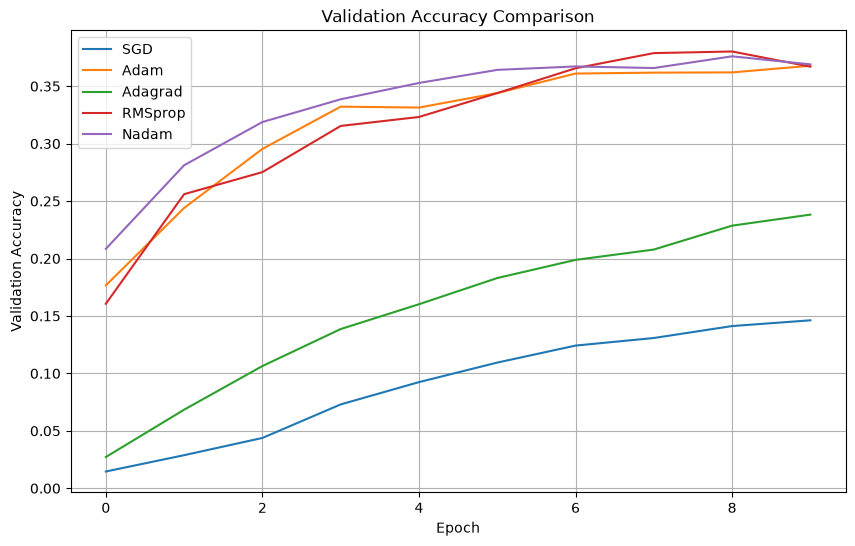

In [18]:
# ============================================================
# CELL 18 - ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

for optimizer_name in optimizer_names:
    
    history = histories[optimizer_name]
    
    plt.plot(
        history["val_accuracy"],
        label=optimizer_name
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "accuracy_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

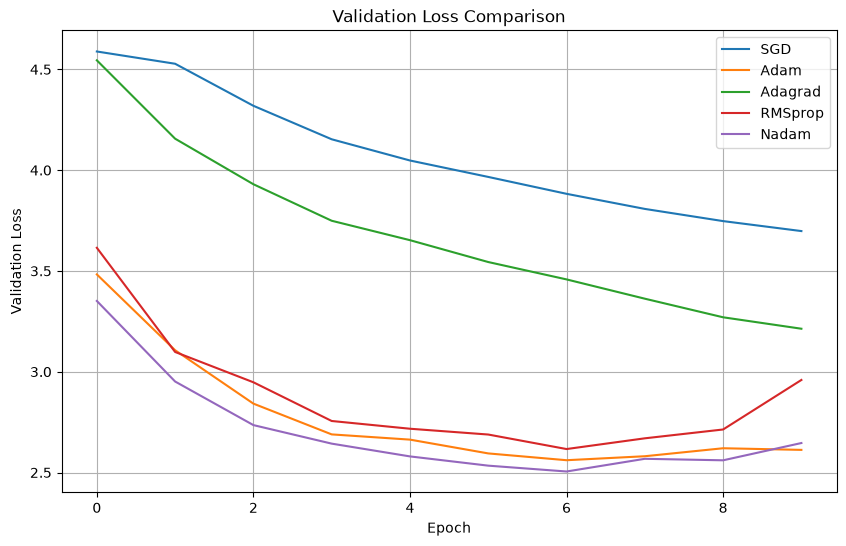

In [19]:
# ============================================================
# CELL 19 - LOSS COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

for optimizer_name in optimizer_names:
    
    history = histories[optimizer_name]
    
    plt.plot(
        history["val_loss"],
        label=optimizer_name
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "loss_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

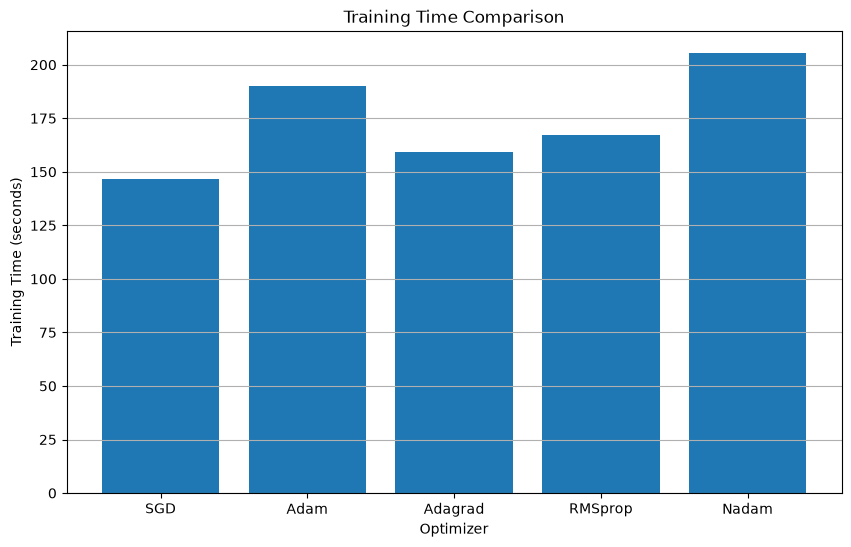

In [20]:
# ============================================================
# CELL 20 - TRAINING TIME COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Optimizer"],
    results_df["Training Time (seconds)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Training Time (seconds)")
plt.grid(axis="y")

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "convergence_time.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

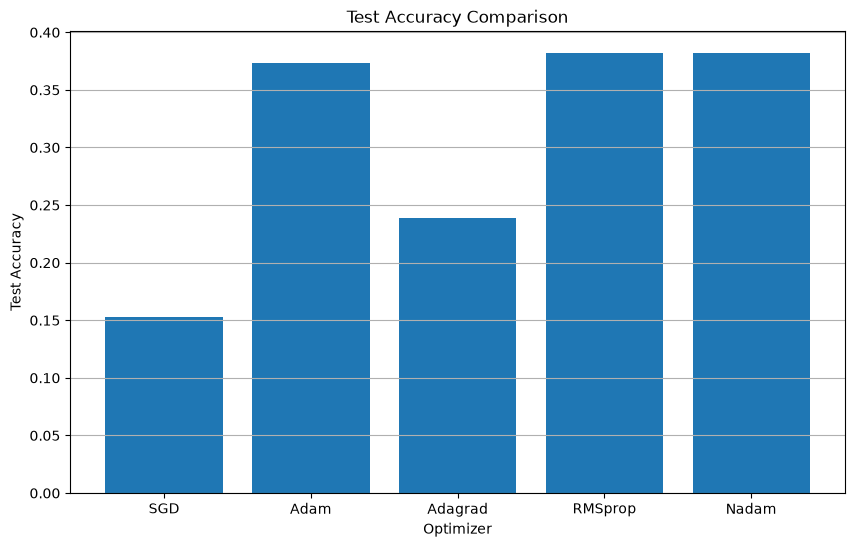

In [21]:
# ============================================================
# CELL 21 - TEST ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Optimizer"],
    results_df["Test Accuracy"]
)

plt.title("Test Accuracy Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Test Accuracy")
plt.grid(axis="y")

plt.show()

In [22]:
# ============================================================
# CELL 22 - FIND BEST OPTIMIZER
# ============================================================

best_optimizer = results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

print("Best Optimizer:")
print(best_optimizer["Optimizer"])

print("\nBest Test Accuracy:")
print(
    round(
        best_optimizer["Test Accuracy"] * 100,
        2
    ),
    "%"
)

Best Optimizer:
RMSprop

Best Test Accuracy:
38.2 %


In [23]:
# ============================================================
# CELL 23 - FIND FASTEST OPTIMIZER
# ============================================================

fastest_optimizer = results_df.loc[
    results_df["Training Time (seconds)"].idxmin()
]

print("Fastest Optimizer:")
print(fastest_optimizer["Optimizer"])

print("\nTraining Time:")
print(
    round(
        fastest_optimizer["Training Time (seconds)"],
        2
    ),
    "seconds"
)

Fastest Optimizer:
SGD

Training Time:
146.48 seconds


In [24]:
# ============================================================
# CELL 24 - FINAL COMPARISON TABLE
# ============================================================

comparison = results_df[
    [
        "Optimizer",
        "Training Time (seconds)",
        "Final Train Accuracy",
        "Final Validation Accuracy",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Test Loss"
    ]
].copy()

comparison["Training Time (seconds)"] = comparison[
    "Training Time (seconds)"
].round(2)

comparison["Final Train Accuracy"] = comparison[
    "Final Train Accuracy"
].round(4)

comparison["Final Validation Accuracy"] = comparison[
    "Final Validation Accuracy"
].round(4)

comparison["Best Validation Accuracy"] = comparison[
    "Best Validation Accuracy"
].round(4)

comparison["Test Accuracy"] = comparison[
    "Test Accuracy"
].round(4)

comparison["Test Loss"] = comparison[
    "Test Loss"
].round(4)

print(comparison.to_string(index=False))

Optimizer  Training Time (seconds)  Final Train Accuracy  Final Validation Accuracy  Best Validation Accuracy  Test Accuracy  Test Loss
      SGD                   146.48                0.1313                     0.1462                    0.1462         0.1529     3.6747
     Adam                   190.19                0.4834                     0.3678                    0.3678         0.3733     2.5472
  Adagrad                   159.07                0.2228                     0.2382                    0.2382         0.2390     3.1831
  RMSprop                   167.05                0.6294                     0.3670                    0.3802         0.3820     2.8825
    Nadam                   205.46                0.5402                     0.3690                    0.3760         0.3817     2.5973


In [25]:
# ============================================================
# CELL 25 - AUTOMATIC CONCLUSION
# ============================================================

best_accuracy_optimizer = results_df.loc[
    results_df["Test Accuracy"].idxmax(),
    "Optimizer"
]

fastest_optimizer_name = results_df.loc[
    results_df["Training Time (seconds)"].idxmin(),
    "Optimizer"
]

lowest_loss_optimizer = results_df.loc[
    results_df["Test Loss"].idxmin(),
    "Optimizer"
]

print("CONCLUSION")
print("-" * 50)

print(
    f"The optimizer with the highest test accuracy was "
    f"{best_accuracy_optimizer}."
)

print(
    f"The fastest optimizer in terms of training time was "
    f"{fastest_optimizer_name}."
)

print(
    f"The optimizer with the lowest test loss was "
    f"{lowest_loss_optimizer}."
)

print(
    "\nTherefore, the experiment demonstrates that "
    "different optimization algorithms produce different "
    "accuracy, loss and convergence behavior."
)

CONCLUSION
--------------------------------------------------
The optimizer with the highest test accuracy was RMSprop.
The fastest optimizer in terms of training time was SGD.
The optimizer with the lowest test loss was Adam.

Therefore, the experiment demonstrates that different optimization algorithms produce different accuracy, loss and convergence behavior.


In [26]:
# ============================================================
# CELL 26 - HYPERPARAMETERS USED
# ============================================================

hyperparameters = pd.DataFrame({
    "Optimizer": [
        "SGD",
        "Adam",
        "Adagrad",
        "RMSprop",
        "Nadam"
    ],
    
    "Learning Rate": [
        0.01,
        0.001,
        0.01,
        0.001,
        0.001
    ],
    
    "Batch Size": [
        BATCH_SIZE,
        BATCH_SIZE,
        BATCH_SIZE,
        BATCH_SIZE,
        BATCH_SIZE
    ]
})

hyperparameters

,Optimizer,Learning Rate,Batch Size
0,SGD,0.010,128
1,Adam,0.001,128
2,Adagrad,0.010,128
3,RMSprop,0.001,128
4,Nadam,0.001,128
